# Week 2 Day 4: Similarity Calculation in Text and Distance Metrics

**Dataset:** `sample_comments.csv` (500 social media style comments, 11 columns)

**What this notebook covers**

| Part | Topic | Techniques |
|------|-------|------------|
| A | Text similarity | Jaccard, Dice, Overlap, Levenshtein, Cosine (Bag of Words), Cosine (TF-IDF) |
| B | Distance metrics on numeric features | Euclidean, Manhattan, Chebyshev, Minkowski, Cosine distance, Mahalanobis |
| C | Distance metrics on binary features | Hamming, Jaccard distance |
| D | Putting it together | Nearest neighbours, near-duplicate detection, comparing metrics |

**Similarity vs distance:** a similarity score is high when two items are alike (1 = identical). A distance is low when two items are alike (0 = identical). They are related, for example `cosine distance = 1 - cosine similarity`.

## 1. Imports and loading the data

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from scipy.spatial import distance

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 140)

df = pd.read_csv("sample_comments.csv")
print("Shape:", df.shape)
df.head()

Shape: (500, 11)


,comment_id,user_id,category,text,likes,replies,word_count,char_count,sentiment_score,is_pinned,posted_at
0,C0001,U095,travel,"Visited Lumbini last autumn, the food was absolutely breathtaking",34,3,9,65,0.252,0,2026-09-04 09:46:00
1,C0002,U004,sports,The coach of Nepal deserves credit for the teamwork this week,2,0,11,61,-0.072,0,2026-09-07 02:42:00
2,C0003,U084,technology,"This phone review is spot on, the speaker really stands out to be fair",11,0,14,70,0.390,0,2026-09-05 19:00:00
3,C0004,U104,food,Can someone share a spicy dal bhat recipe with less chili in my opinion,100,1,14,71,0.939,0,2026-09-07 08:26:00
4,C0005,U013,food,"I tried making biryani at home, the garlic was too spicy really",6,0,12,63,0.510,0,2026-09-19 01:51:00


In [2]:
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Comments per category:")
print(df["category"].value_counts())

comment_id             str
user_id                str
category               str
text                   str
likes                int64
replies              int64
word_count           int64
char_count           int64
sentiment_score    float64
is_pinned            int64
posted_at              str
dtype: object

Missing values per column:
comment_id         0
user_id            0
category           0
text               0
likes              0
replies            0
word_count         0
char_count         0
sentiment_score    0
is_pinned          0
posted_at          0
dtype: int64

Comments per category:
category
food          131
technology    113
education      91
travel         89
sports         76
Name: count, dtype: int64


### Column guide

| Column | Meaning | Used for |
|--------|---------|----------|
| `comment_id`, `user_id` | Identifiers | Reference only |
| `category` | Topic of the comment (technology, food, travel, sports, education) | Checking that similar text groups by topic |
| `text` | The comment | **Part A** text similarity |
| `likes`, `replies`, `word_count`, `char_count`, `sentiment_score` | Numeric features | **Part B** distance metrics |
| `is_pinned` | 0/1 flag | **Part C** binary distances |
| `posted_at` | Timestamp | Not used here |

## 2. Text preprocessing

Similarity on raw text is noisy because of capital letters, punctuation and filler words. We lowercase, strip punctuation and remove a small set of common stop words.

In [3]:
STOPWORDS = {
    "a", "an", "the", "is", "are", "was", "were", "be", "to", "of", "in", "on", "for",
    "and", "or", "it", "this", "that", "with", "at", "by", "i", "my", "me", "we", "you",
    "so", "too", "very", "as", "from", "has", "have", "had", "can", "will",
}


def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def tokenize(text):
    return [t for t in clean_text(text).split() if t not in STOPWORDS]


df["clean_text"] = df["text"].apply(clean_text)
df["tokens"] = df["text"].apply(tokenize)

df[["text", "clean_text", "tokens"]].head(5)

,text,clean_text,tokens
0,"Visited Lumbini last autumn, the food was absolutely breathtaking",visited lumbini last autumn the food was absolutely breathtaking,"[visited, lumbini, last, autumn, food, absolutely, breathtaking]"
1,The coach of Nepal deserves credit for the teamwork this week,the coach of nepal deserves credit for the teamwork this week,"[coach, nepal, deserves, credit, teamwork, week]"
2,"This phone review is spot on, the speaker really stands out to be fair",this phone review is spot on the speaker really stands out to be fair,"[phone, review, spot, speaker, really, stands, out, fair]"
3,Can someone share a spicy dal bhat recipe with less chili in my opinion,can someone share a spicy dal bhat recipe with less chili in my opinion,"[someone, share, spicy, dal, bhat, recipe, less, chili, opinion]"
4,"I tried making biryani at home, the garlic was too spicy really",i tried making biryani at home the garlic was too spicy really,"[tried, making, biryani, home, garlic, spicy, really]"


# Part A: Text similarity

## 3. Similarity measures from scratch

| Measure | Formula | Works on | Idea |
|---------|---------|----------|------|
| Jaccard | `|A ∩ B| / |A ∪ B|` | word sets | shared words out of all distinct words |
| Dice | `2|A ∩ B| / (|A| + |B|)` | word sets | like Jaccard but rewards overlap more |
| Overlap | `|A ∩ B| / min(|A|, |B|)` | word sets | 1 when the shorter text is inside the longer one |
| Levenshtein | minimum single-character edits | characters | spelling level closeness |
| Cosine | `A·B / (‖A‖ ‖B‖)` | word vectors | angle between count or TF-IDF vectors |

In [4]:
def jaccard_similarity(tokens_a, tokens_b):
    a, b = set(tokens_a), set(tokens_b)
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)


def dice_similarity(tokens_a, tokens_b):
    a, b = set(tokens_a), set(tokens_b)
    if not a and not b:
        return 1.0
    return 2 * len(a & b) / (len(a) + len(b))


def overlap_similarity(tokens_a, tokens_b):
    a, b = set(tokens_a), set(tokens_b)
    if not a or not b:
        return 0.0
    return len(a & b) / min(len(a), len(b))


def levenshtein_distance(s1, s2):
    # Dynamic programming: dp[i][j] = edits to turn s1[:i] into s2[:j]
    m, n = len(s1), len(s2)
    dp = np.zeros((m + 1, n + 1), dtype=int)
    dp[:, 0] = np.arange(m + 1)
    dp[0, :] = np.arange(n + 1)
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if s1[i - 1] == s2[j - 1] else 1
            dp[i, j] = min(dp[i - 1, j] + 1,        # deletion
                           dp[i, j - 1] + 1,        # insertion
                           dp[i - 1, j - 1] + cost) # substitution
    return int(dp[m, n])


def levenshtein_similarity(s1, s2):
    longest = max(len(s1), len(s2))
    return 1.0 if longest == 0 else 1 - levenshtein_distance(s1, s2) / longest


def cosine_text_similarity(text_a, text_b, vectorizer_cls=CountVectorizer):
    vec = vectorizer_cls().fit([text_a, text_b])
    X = vec.transform([text_a, text_b])
    return float(cosine_similarity(X[0], X[1])[0, 0])


# Sanity checks with known answers
print("levenshtein('kitten', 'sitting') =", levenshtein_distance("kitten", "sitting"), "(expected 3)")
print("jaccard(['a','b','c'], ['b','c','d']) =", jaccard_similarity(["a", "b", "c"], ["b", "c", "d"]), "(expected 0.5)")

levenshtein('kitten', 'sitting') = 3 (expected 3)
jaccard(['a','b','c'], ['b','c','d']) = 0.5 (expected 0.5)


## 4. Worked example on three hand written sentences

In [5]:
s1 = "The new phone has a great battery"
s2 = "The new phone has a great camera"
s3 = "Visited Pokhara last spring, the views were breathtaking"

pairs = {"s1 vs s2 (almost same)": (s1, s2),
         "s1 vs s3 (different topic)": (s1, s3),
         "s2 vs s3 (different topic)": (s2, s3)}

rows = []
for name, (a, b) in pairs.items():
    ta, tb = tokenize(a), tokenize(b)
    ca, cb = clean_text(a), clean_text(b)
    rows.append({
        "pair": name,
        "jaccard": jaccard_similarity(ta, tb),
        "dice": dice_similarity(ta, tb),
        "overlap": overlap_similarity(ta, tb),
        "levenshtein_sim": levenshtein_similarity(ca, cb),
        "cosine_bow": cosine_text_similarity(ca, cb),
    })

pd.DataFrame(rows).set_index("pair").round(3)

,jaccard,dice,overlap,levenshtein_sim,cosine_bow
pair,,,,,
s1 vs s2 (almost same),0.6,0.75,0.75,0.879,0.833
s1 vs s3 (different topic),0.0,0.00,0.00,0.273,0.144
s2 vs s3 (different topic),0.0,0.00,0.00,0.291,0.144


**Reading the table:** the first pair differs by one word, so every measure is high. The other two pairs share almost no words, so Jaccard, Dice, Overlap and Cosine drop to 0 or close to it. Levenshtein stays above 0 even for unrelated sentences because it compares *characters*, and any two English sentences share many letters in similar positions. That is why it is used for typo and spelling matching rather than topic matching.

## 5. Cosine similarity with TF-IDF on the whole dataset

Bag of Words counts treat every word equally. **TF-IDF** gives less weight to words that appear in many comments (for example "great") and more weight to words that are distinctive. We fit it once on all 500 comments and get a 500 x 500 similarity matrix.

In [6]:
tfidf = TfidfVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x, token_pattern=None, lowercase=False)
X_tfidf = tfidf.fit_transform(df["tokens"])

bow = CountVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x, token_pattern=None, lowercase=False)
X_bow = bow.fit_transform(df["tokens"])

print("Vocabulary size:", len(tfidf.vocabulary_))
print("TF-IDF matrix shape:", X_tfidf.shape)

sim_tfidf = cosine_similarity(X_tfidf)
sim_bow = cosine_similarity(X_bow)
print("Similarity matrix shape:", sim_tfidf.shape)
print("Diagonal is all 1.0:", np.allclose(np.diag(sim_tfidf), 1.0))

Vocabulary size: 181
TF-IDF matrix shape: (500, 181)
Similarity matrix shape: (500, 500)
Diagonal is all 1.0: True


### Top 10 most similar comment pairs (TF-IDF cosine)

In [7]:
iu = np.triu_indices_from(sim_tfidf, k=1)          # upper triangle, each pair once
order = np.argsort(sim_tfidf[iu])[::-1][:10]

top_pairs = pd.DataFrame({
    "idx_a": iu[0][order],
    "idx_b": iu[1][order],
    "cosine_tfidf": sim_tfidf[iu][order].round(3),
    "cosine_bow": sim_bow[iu][order].round(3),
    "category_a": df["category"].values[iu[0][order]],
    "category_b": df["category"].values[iu[1][order]],
    "text_a": df["text"].values[iu[0][order]],
    "text_b": df["text"].values[iu[1][order]],
})
top_pairs

,idx_a,idx_b,cosine_tfidf,cosine_bow,category_a,category_b,text_a,text_b
0,125,324,1.0,1.0,education,education,"Final year exam on databases is near, please share notes about clustering","Final year exam on databases is near, please share notes about clustering"
1,125,176,1.0,1.0,education,education,"Final year exam on databases is near, please share notes about clustering","Final year exam on databases is near, please share notes about clustering"
2,65,390,1.0,1.0,technology,technology,"This phone review is spot on, the display really stands out","This phone review is spot on, the display really stands out"
3,176,324,1.0,1.0,education,education,"Final year exam on databases is near, please share notes about clustering","Final year exam on databases is near, please share notes about clustering"
4,286,411,1.0,1.0,education,education,"I am struggling with regression in python, can anyone suggest a practical resource","I am struggling with regression in python, can anyone suggest a practical resource"
5,297,447,1.0,1.0,travel,travel,"Chitwan is overrated, the trekking was crowded and expensive really","Chitwan is overrated, the trekking was crowded and expensive really"
6,58,73,1.0,1.0,sports,sports,"What a match by Barcelona, the passing from the captain was incredible in my opinion","What a match by Barcelona, the passing from the captain was incredible in my opinion"
7,320,490,1.0,1.0,education,education,Learning regression for python is practical once practice daily,Learning regression for python is practical once you practice daily
8,145,491,1.0,1.0,sports,sports,"Proud of Gorkhali, the teamwork in the second half changed the game really","Proud of Gorkhali, the teamwork in the second half changed the game really"
9,312,490,1.0,1.0,education,education,Learning regression for python is practical once you practice daily,Learning regression for python is practical once you practice daily


The highest pairs score 1.0: they are repeats of the same comment (some differ only by a filler word that carries no weight after cleaning). Both comments in each pair belong to the same category. Section 13 shows the slightly lower scoring near-duplicates (about 0.9 to 0.99), where a word was dropped or added.

## 6. Does text similarity respect topics?

In [8]:
cats = sorted(df["category"].unique())
cat_idx = {c: np.where(df["category"].values == c)[0] for c in cats}

mean_sim = pd.DataFrame(index=cats, columns=cats, dtype=float)
for a in cats:
    for b in cats:
        block = sim_tfidf[np.ix_(cat_idx[a], cat_idx[b])]
        if a == b:
            n = block.shape[0]
            mean_sim.loc[a, b] = (block.sum() - n) / (n * (n - 1))   # ignore the diagonal
        else:
            mean_sim.loc[a, b] = block.mean()

print("Average TF-IDF cosine similarity between categories:")
mean_sim.round(3)

Average TF-IDF cosine similarity between categories:


,education,food,sports,technology,travel
education,0.195,0.009,0.005,0.018,0.005
food,0.009,0.200,0.006,0.008,0.007
sports,0.005,0.006,0.189,0.007,0.008
technology,0.018,0.008,0.007,0.193,0.014
travel,0.005,0.007,0.008,0.014,0.191


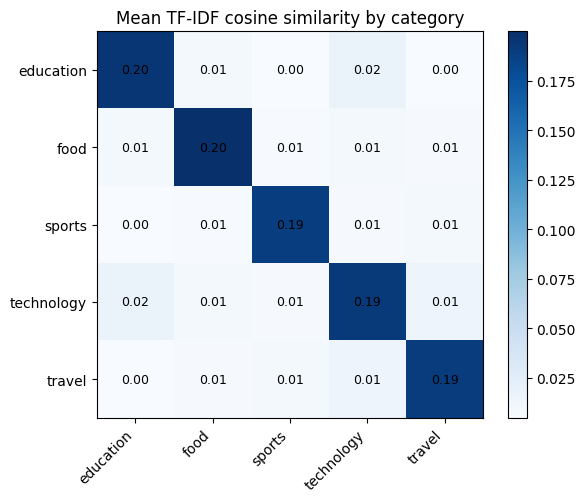

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mean_sim.values.astype(float), cmap="Blues")
ax.set_xticks(range(len(cats)))
ax.set_yticks(range(len(cats)))
ax.set_xticklabels(cats, rotation=45, ha="right")
ax.set_yticklabels(cats)
for i in range(len(cats)):
    for j in range(len(cats)):
        ax.text(j, i, f"{mean_sim.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Mean TF-IDF cosine similarity by category")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

The diagonal (same category) is clearly higher than the off-diagonal cells, so the similarity score recovers the topic structure without ever seeing the `category` column.

## 7. Search: find the comments most similar to a query

In [10]:
def most_similar(query, n=5):
    q_tokens = tokenize(query)
    q_vec = tfidf.transform([q_tokens])
    scores = cosine_similarity(q_vec, X_tfidf).ravel()
    best = np.argsort(scores)[::-1][:n]
    return pd.DataFrame({
        "score": scores[best].round(3),
        "category": df["category"].values[best],
        "text": df["text"].values[best],
    })


print("Query: 'battery life of the new phone is great'")
most_similar("battery life of the new phone is great")

Query: 'battery life of the new phone is great'


,score,category,text
0,0.776,technology,The new phone has a great battery and the software is amazing really
1,0.595,technology,The new smartwatch has a great battery and the software is amazing in my opinion
2,0.589,technology,The new phone has a great camera and the price is amazing
3,0.578,technology,The new camera has a great battery and the performance is amazing really
4,0.563,technology,The new phone has a great camera and the software is amazing to be fair


In [11]:
print("Query: 'best momo recipe with spicy chili'")
most_similar("best momo recipe with spicy chili")

Query: 'best momo recipe with spicy chili'


,score,category,text
0,0.504,food,"Best momo in town, you must try it with extra chili"
1,0.487,food,"Best momo in town, you must try it with extra chili in my opinion"
2,0.483,food,"Best momo in town, you must try it with extra chili to be fair"
3,0.479,food,Can someone share a crispy momo recipe with less chili
4,0.473,food,Can someone share a sweet momo recipe with less chili


## 8. Comparing text measures on the same pairs

In [12]:
sample_pairs = [(int(a), int(b)) for a, b in zip(iu[0][order][:3], iu[1][order][:3])]   # near duplicates
rng = np.random.default_rng(0)
same_cat = []
while len(same_cat) < 3:
    a, b = rng.choice(len(df), 2, replace=False)
    if df["category"].iloc[a] == df["category"].iloc[b]:
        same_cat.append((int(a), int(b)))
diff_cat = []
while len(diff_cat) < 3:
    a, b = rng.choice(len(df), 2, replace=False)
    if df["category"].iloc[a] != df["category"].iloc[b]:
        diff_cat.append((int(a), int(b)))

records = []
for label, plist in [("near duplicate", sample_pairs), ("same category", same_cat), ("different category", diff_cat)]:
    for a, b in plist:
        ta, tb = df["tokens"].iloc[a], df["tokens"].iloc[b]
        ca, cb = df["clean_text"].iloc[a], df["clean_text"].iloc[b]
        records.append({
            "pair_type": label,
            "jaccard": jaccard_similarity(ta, tb),
            "dice": dice_similarity(ta, tb),
            "overlap": overlap_similarity(ta, tb),
            "levenshtein": levenshtein_similarity(ca, cb),
            "cosine_bow": sim_bow[a, b],
            "cosine_tfidf": sim_tfidf[a, b],
        })

comparison = pd.DataFrame(records)
comparison.round(3)

,pair_type,jaccard,dice,overlap,levenshtein,cosine_bow,cosine_tfidf
0,near duplicate,1.000,1.000,1.000,1.000,1.000,1.000
1,near duplicate,1.000,1.000,1.000,1.000,1.000,1.000
2,near duplicate,1.000,1.000,1.000,1.000,1.000,1.000
3,same category,0.231,0.375,0.375,0.257,0.375,0.353
4,same category,0.077,0.143,0.143,0.257,0.143,0.158
5,same category,0.000,0.000,0.000,0.239,0.000,0.000
6,different category,0.067,0.125,0.125,0.370,0.125,0.069
7,different category,0.000,0.000,0.000,0.293,0.000,0.000
8,different category,0.000,0.000,0.000,0.279,0.000,0.000


In [13]:
print("Average score by pair type")
comparison.groupby("pair_type").mean().round(3).loc[["near duplicate", "same category", "different category"]]

Average score by pair type


,jaccard,dice,overlap,levenshtein,cosine_bow,cosine_tfidf
pair_type,,,,,,
near duplicate,1.000,1.000,1.000,1.000,1.000,1.000
same category,0.103,0.173,0.173,0.251,0.173,0.170
different category,0.022,0.042,0.042,0.314,0.042,0.023


# Part B: Distance metrics on numeric features

Now we compare comments by their numbers: `likes`, `replies`, `word_count`, `char_count` and `sentiment_score`.

## 9. Why scaling matters

In [14]:
num_cols = ["likes", "replies", "word_count", "char_count", "sentiment_score"]
df[num_cols].describe().round(2)

,likes,replies,word_count,char_count,sentiment_score
count,500.00,500.00,500.00,500.00,500.00
mean,41.03,3.37,12.14,69.93,0.27
std,67.67,5.84,1.86,9.73,0.36
min,0.00,0.00,8.00,49.00,-0.99
25%,10.00,0.00,11.00,63.00,0.02
50%,20.00,2.00,12.00,69.00,0.29
75%,43.00,4.00,13.00,76.00,0.50
max,939.00,78.00,19.00,113.00,1.00


In [15]:
X_raw = df[num_cols].values.astype(float)

a_raw, b_raw = X_raw[0], X_raw[1]
print("Row 0:", a_raw)
print("Row 1:", b_raw)
print("Per-feature absolute difference:", np.abs(a_raw - b_raw).round(2))
print("Euclidean distance on RAW data:", round(float(distance.euclidean(a_raw, b_raw)), 3))

Row 0: [34.     3.     9.    65.     0.252]
Row 1: [ 2.     0.    11.    61.    -0.072]
Per-feature absolute difference: [32.    3.    2.    4.    0.32]
Euclidean distance on RAW data: 32.452


`char_count` and `likes` have far larger ranges than `sentiment_score` (which lives between -1 and 1), so they dominate the raw distance. Standardising each column to mean 0 and standard deviation 1 puts all features on the same footing.

In [16]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Means after scaling:", X.mean(axis=0).round(3))
print("Std after scaling:  ", X.std(axis=0).round(3))
print()
a, b = X[0], X[1]
print("Per-feature absolute difference (scaled):", np.abs(a - b).round(3))
print("Euclidean distance on SCALED data:", round(float(distance.euclidean(a, b)), 3))

Means after scaling: [ 0. -0.  0.  0. -0.]
Std after scaling:   [1. 1. 1. 1. 1.]

Per-feature absolute difference (scaled): [0.473 0.514 1.077 0.411 0.89 ]
Euclidean distance on SCALED data: 1.616


## 10. The distance metrics

| Metric | Formula | Notes |
|--------|---------|-------|
| Euclidean (L2) | `sqrt(Σ (aᵢ - bᵢ)²)` | straight line distance, penalises large gaps |
| Manhattan (L1) | `Σ |aᵢ - bᵢ|` | sum of gaps, less sensitive to one big gap |
| Chebyshev (L∞) | `max |aᵢ - bᵢ|` | only the single largest gap matters |
| Minkowski (p) | `(Σ |aᵢ - bᵢ|ᵖ)^(1/p)` | general form: p=1 Manhattan, p=2 Euclidean, p=∞ Chebyshev |
| Cosine distance | `1 - A·B / (‖A‖‖B‖)` | compares direction, ignores magnitude |
| Mahalanobis | `sqrt((a-b)ᵀ S⁻¹ (a-b))` | accounts for correlation between features (S = covariance matrix) |

In [17]:
def euclidean(a, b):
    return float(np.sqrt(np.sum((a - b) ** 2)))


def manhattan(a, b):
    return float(np.sum(np.abs(a - b)))


def chebyshev(a, b):
    return float(np.max(np.abs(a - b)))


def minkowski(a, b, p=3):
    return float(np.sum(np.abs(a - b) ** p) ** (1 / p))


def cosine_distance(a, b):
    return float(1 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


print("Feature correlations (why Mahalanobis can matter):")
print(pd.DataFrame(X, columns=num_cols).corr().round(2))
print()

VI = np.linalg.inv(np.cov(X, rowvar=False))      # inverse covariance of the scaled data


def mahalanobis(a, b, VI=VI):
    d = a - b
    return float(np.sqrt(d @ VI @ d))


a, b = X[0], X[1]
manual = {
    "euclidean": euclidean(a, b),
    "manhattan": manhattan(a, b),
    "chebyshev": chebyshev(a, b),
    "minkowski_p3": minkowski(a, b, 3),
    "cosine": cosine_distance(a, b),
    "mahalanobis": mahalanobis(a, b),
}
library = {
    "euclidean": distance.euclidean(a, b),
    "manhattan": distance.cityblock(a, b),
    "chebyshev": distance.chebyshev(a, b),
    "minkowski_p3": distance.minkowski(a, b, 3),
    "cosine": distance.cosine(a, b),
    "mahalanobis": distance.mahalanobis(a, b, VI),
}

check = pd.DataFrame({"manual": manual, "scipy": library})
check["match"] = np.isclose(check["manual"], check["scipy"])
check.round(4)

Feature correlations (why Mahalanobis can matter):
                 likes  replies  word_count  char_count  sentiment_score
likes             1.00     0.95       -0.06       -0.03            -0.04
replies           0.95     1.00       -0.04       -0.02            -0.04
word_count       -0.06    -0.04        1.00        0.68            -0.02
char_count       -0.03    -0.02        0.68        1.00            -0.10
sentiment_score  -0.04    -0.04       -0.02       -0.10             1.00



,manual,scipy,match
euclidean,1.6161,1.6161,True
manhattan,3.3669,3.3669,True
chebyshev,1.0775,1.0775,True
minkowski_p3,1.3140,1.3140,True
cosine,0.4429,0.4429,True
mahalanobis,2.2437,2.2437,True


Every hand written metric matches SciPy, so the formulas are implemented correctly.

## 11. Distance matrix and nearest neighbours

In [18]:
metrics = {
    "euclidean": "euclidean",
    "manhattan": "cityblock",
    "chebyshev": "chebyshev",
    "cosine": "cosine",
    "mahalanobis": "mahalanobis",
}

dist_matrices = {}
for name, metric in metrics.items():
    if metric == "mahalanobis":
        dist_matrices[name] = distance.cdist(X, X, metric="mahalanobis", VI=VI)
    else:
        dist_matrices[name] = distance.cdist(X, X, metric=metric)

print("Each distance matrix has shape:", dist_matrices["euclidean"].shape)
print("Diagonal is zero:", np.allclose(np.diag(dist_matrices["euclidean"]), 0))

Each distance matrix has shape: (500, 500)
Diagonal is zero: True


In [19]:
def nearest(idx, metric, k=5):
    d = dist_matrices[metric][idx].copy()
    d[idx] = np.inf                       # exclude the item itself
    nn = np.argsort(d)[:k]
    return nn


query_idx = 0
print("Query comment:", df["text"].iloc[query_idx])
print("Features:", dict(zip(num_cols, X_raw[query_idx].round(2).tolist())))
print()

neighbours = pd.DataFrame({m: nearest(query_idx, m) for m in metrics})
neighbours.index = [f"rank {i}" for i in range(1, 6)]
neighbours

Query comment: Visited Lumbini last autumn, the food was absolutely breathtaking
Features: {'likes': 34.0, 'replies': 3.0, 'word_count': 9.0, 'char_count': 65.0, 'sentiment_score': 0.25}



,euclidean,manhattan,chebyshev,cosine,mahalanobis
rank 1,485,188,485,485,485
rank 2,188,485,423,188,423
rank 3,423,162,188,423,392
rank 4,162,423,392,162,188
rank 5,392,392,162,293,162


In [20]:
# How much do the metrics agree with Euclidean on the 5 nearest neighbours, averaged over 100 queries?
rng = np.random.default_rng(1)
queries = rng.choice(len(df), 100, replace=False)

agreement = {}
for m in metrics:
    overlaps = [len(set(nearest(q, "euclidean")) & set(nearest(q, m))) / 5 for q in queries]
    agreement[m] = np.mean(overlaps)

pd.DataFrame({"avg overlap with Euclidean top 5": agreement}).round(2)

,avg overlap with Euclidean top 5
euclidean,1.00
manhattan,0.78
chebyshev,0.71
cosine,0.52
mahalanobis,0.48


Manhattan and Chebyshev are the closest relatives of Euclidean (all three are Minkowski distances), so they share most neighbours. Cosine distance agrees about half the time, since it ignores how large the feature values are and looks only at the direction of the vector. Mahalanobis also differs a lot because it discounts differences along correlated features (`likes` and `replies` have a correlation of about 0.95, so a gap in both is not treated as two independent gaps).

# Part C: Distance metrics on binary features

## 12. Hamming and Jaccard distance

Binary flags describe each comment with yes/no answers. Hamming distance is the fraction of flags that differ. Jaccard distance ignores flags where both are 0 and focuses on the ones that are "on".

In [21]:
bin_df = pd.DataFrame({
    "is_pinned": df["is_pinned"],
    "high_likes": (df["likes"] > df["likes"].median()).astype(int),
    "has_replies": (df["replies"] > 0).astype(int),
    "positive": (df["sentiment_score"] > 0).astype(int),
    "long_text": (df["word_count"] > df["word_count"].median()).astype(int),
})
B = bin_df.values.astype(bool)

print(bin_df.head())
print()
print("Row 0:", B[0].astype(int), " Row 3:", B[3].astype(int))
print("Hamming distance (fraction differing):", round(float(distance.hamming(B[0], B[3])), 3))
print("Jaccard distance:", round(float(distance.jaccard(B[0], B[3])), 3))

   is_pinned  high_likes  has_replies  positive  long_text
0          0           1            1         1          0
1          0           0            0         0          0
2          0           0            0         1          1
3          0           1            1         1          1
4          0           0            0         1          0

Row 0: [0 1 1 1 0]  Row 3: [0 1 1 1 1]
Hamming distance (fraction differing): 0.2
Jaccard distance: 0.25


In [22]:
def hamming_manual(a, b):
    return float(np.mean(a != b))


def jaccard_distance_manual(a, b):
    union = np.sum(a | b)
    return 0.0 if union == 0 else float(1 - np.sum(a & b) / union)


print("Manual Hamming  :", round(hamming_manual(B[0], B[3]), 3))
print("Manual Jaccard  :", round(jaccard_distance_manual(B[0], B[3]), 3))

Manual Hamming  : 0.2
Manual Jaccard  : 0.25


# Part D: Putting it together

## 13. Near-duplicate detection with a threshold

A common data engineering task is removing near-duplicate records. Pairs with TF-IDF cosine similarity above a threshold are flagged.

In [23]:
threshold = 0.90
mask = sim_tfidf[iu] >= threshold

dups = pd.DataFrame({
    "idx_a": iu[0][mask],
    "idx_b": iu[1][mask],
    "similarity": sim_tfidf[iu][mask].round(3),
})
print(f"Pairs with similarity >= {threshold}: {len(dups)}")

# Keep the first comment of each duplicate pair, drop the later one
drop_idx = sorted(set(dups["idx_b"]))
df_dedup = df.drop(index=drop_idx).reset_index(drop=True)
print(f"Rows before: {len(df)}, rows after removing near-duplicates: {len(df_dedup)}")

Pairs with similarity >= 0.9: 188


Rows before: 500, rows after removing near-duplicates: 358


In [24]:
# Show a few flagged pairs
view = dups.head(5).copy()
view["text_a"] = df["text"].values[view["idx_a"]]
view["text_b"] = df["text"].values[view["idx_b"]]
view

,idx_a,idx_b,similarity,text_a,text_b
0,1,9,0.919,The coach of Nepal deserves credit for the teamwork this week,The coach of deserves credit for the teamwork this week
1,2,107,0.930,"This phone review is spot on, the speaker really stands out to be fair","This phone review is spot on, the speaker really stands out really"
2,3,7,0.935,Can someone share a spicy dal bhat recipe with less chili in my opinion,Can someone share a spicy dal recipe with less chili in my opinion
3,3,239,0.935,Can someone share a spicy dal bhat recipe with less chili in my opinion,Can someone share a spicy dal bhat recipe with less chili honestly
4,4,90,0.926,"I tried making biryani at home, the garlic was too spicy really","I tried making biryani at home, the garlic was too spicy honestly"


## 14. Summary

| Measure | Type | Range | Best used for | Weakness |
|---------|------|-------|---------------|----------|
| Jaccard / Dice / Overlap | text similarity (word sets) | 0 to 1 | quick set comparison, tags, short text | ignores word frequency and order |
| Levenshtein | text similarity (characters) | 0 to 1 (normalised) | typos, name matching, fuzzy join | slow on long text, ignores meaning |
| Cosine (Bag of Words) | text similarity (vectors) | 0 to 1 | topic similarity | common words add noise |
| Cosine (TF-IDF) | text similarity (vectors) | 0 to 1 | search, recommendation, de-duplication | needs a fitted vocabulary |
| Euclidean | numeric distance | 0 to ∞ | scaled continuous features | sensitive to scale and outliers |
| Manhattan | numeric distance | 0 to ∞ | high dimensional or outlier prone data | not rotation invariant |
| Chebyshev | numeric distance | 0 to ∞ | worst case difference matters | ignores all but one feature |
| Minkowski | numeric distance | 0 to ∞ | tunable generalisation (p) | p must be chosen |
| Cosine distance | numeric distance | 0 to 2 | direction matters more than size | ignores magnitude |
| Mahalanobis | numeric distance | 0 to ∞ | correlated features | needs an invertible covariance matrix |
| Hamming / Jaccard | binary distance | 0 to 1 | flags, categorical encodings | loses magnitude information |

**Key takeaways**

1. Always scale numeric features before using Euclidean, Manhattan or Chebyshev distance.
2. Clean the text first (lowercase, punctuation, stop words) or similarity scores will be dominated by noise.
3. TF-IDF cosine similarity is the default choice for comparing documents; Levenshtein is for spelling level matches.
4. Verify hand written metrics against SciPy, as done in section 10.
5. Similarity matrices grow with n squared (500 rows gives 250,000 pairs), so for millions of records use approximate nearest neighbour methods instead of a full matrix.